In [35]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

from lmfit import models

In [36]:
# nozzle sizes in mu m
noz_ID = [32,32,32,64,64,64]

# measured D[4][3]
mean_diam = [179.76864624, 184.3699646, 177.406326294, 246.732009888, 254.487854004, 491.828399658]


In [37]:
# Guess for error in nozzle ID
err_noz_ID = [1]*6

# measured error in D[4][3]
err_mean_diam = [19.3167552948, 17.9351501465, 19.3943424225, 31.3087768555, 34.9372062683, 83.3335037231]

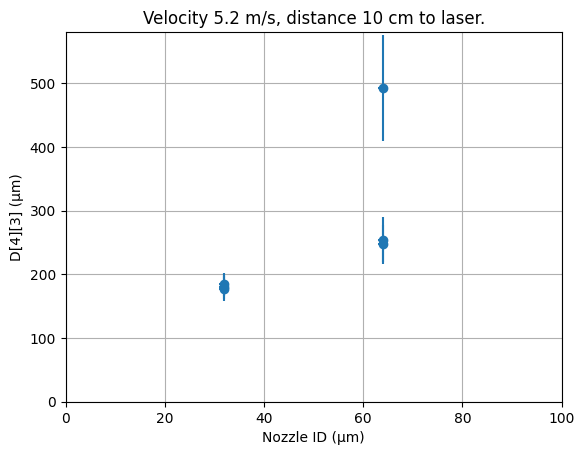

In [38]:
plt.figure(figsize=(10,6))

plt.errorbar(noz_ID, mean_diam, xerr=err_noz_ID, yerr=err_mean_diam, fmt='o')

plt.title(r"Velocity 5.2 m/s, distance 10 cm to laser.")
plt.xlabel(r"Nozzle ID (μm)")
plt.ylabel(r"D[4][3] (μm)")

plt.xlim(0, 100)
plt.ylim(0, 580)

plt.grid(True)

## Normalized data

In [39]:
# devide the average by by the nozzle ID and you'll get a normalized ratio

mean_diam_norm = [2.94157, 3.01683, 2.90226, 2.01826, 2.08171, 4.02346]

In [40]:

# normalized error
err_mean_diam_norm = [0.31605, 0.29344, 0.31732, 0.25612, 0.28581, 0.68173]

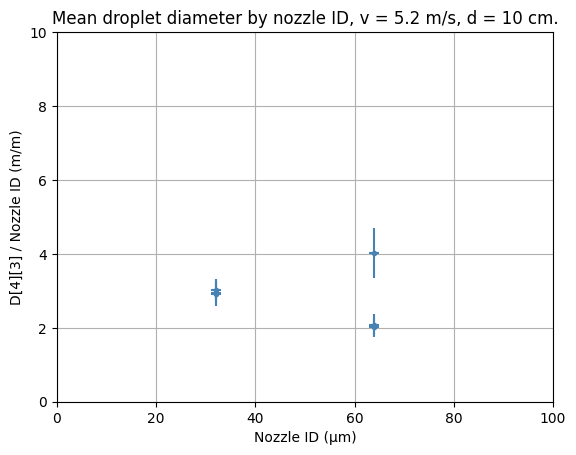

In [41]:
plt.figure()

plt.errorbar(noz_ID, mean_diam_norm, xerr=err_noz_ID, yerr=err_mean_diam_norm, fmt='.', color="steelblue")

plt.title(r"Mean droplet diameter by nozzle ID, v = 5.2 m/s, d = 10 cm.")
plt.xlabel(r"Nozzle ID (μm)")
plt.ylabel(r"D[4][3] / Nozzle ID (m/m)")

plt.xlim(0, 100)
plt.ylim(0, 10)

plt.grid(True)

## fit

In [42]:
def fit_function(x_fit, p1, p2,p3):
    mean_diam_fit = p1 * x_fit + p2  
    return mean_diam_fit

In [43]:
fit_model = models.Model(fit_function)

err_mean_diam_norm_array = np.array(err_mean_diam_norm)
err_mean_diam_norm_inv = 1 / err_mean_diam_norm_array

fit_result = fit_model.fit(mean_diam_norm, x_fit=np.array(noz_ID), weights=err_mean_diam_norm_inv, p1=1, p2=1)

C:\Users\Nina van Iperen\AppData\Local\Temp\ipykernel_30224\2281195254.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
C:\Users\tryst\AppData\Local\Temp\ipykernel_9024\2362999847.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(noz_ID, fit_result.best_fit, 'r-', color="red")


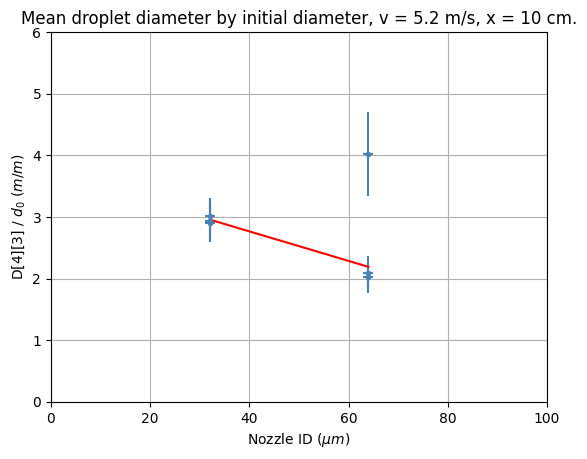

In [44]:
plt.figure(figsize=(10, 6))
plt.tight_layout()

plt.errorbar(noz_ID, mean_diam_norm, xerr=err_noz_ID, yerr=err_mean_diam_norm, fmt='.', color="steelblue")
plt.plot(noz_ID, fit_result.best_fit, 'r-', color="red")

plt.title(r"Mean droplet diameter by initial diameter, v = 5.2 m/s, x = 10 cm.")
plt.xlabel(r"Nozzle ID ($\mu m$)")
plt.ylabel(r"D[4][3] / $d_0$ ($m/m$)")

plt.xlim(0, 100)
plt.ylim(0, 6)

plt.grid(True)

In [45]:
print(fit_result.fit_report())

[[Model]]
    Model(fit_function)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 6
    # variables        = 3
    chi-square         = 7.89989396
    reduced chi-square = 2.63329799
    Akaike info crit   = 7.65053920
    Bayesian info crit = 7.02581761
    R-squared          = -0.26474732
##  Warning: uncertainties could not be estimated:
    p3:  at initial value
    p3:  at boundary
[[Variables]]
    p1: -0.02396419 (init = 1)
    p2:  3.72375025 (init = 1)
    p3:        -inf (init = -inf)
